# DeepAR-lite Forecasting for CPI MoM Inflation

Clean probabilistic DeepAR-style notebook for CPI forecasting. The model outputs a Gaussian mean and uncertainty parameter, then evaluates point forecasts and prediction intervals.

In [1]:
import os, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, Add, Concatenate, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import L1L2

plt.style.use("seaborn-v0_8-darkgrid")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.backend.clear_session()

DATA_DIR = os.path.join(os.getcwd(), "data", "processed")

from tensorflow.keras.layers import GRU, LSTM
from tensorflow.keras.losses import Loss
OUTPUT_DIR = os.path.join(os.getcwd(), "outputs", "step8_deepar")
os.makedirs(OUTPUT_DIR, exist_ok=True)
MODEL_NAME = "DeepAR-lite"
MODEL_TAG = "deepar"
LOSS_LABEL = "Gaussian NLL"

In [2]:
target_var = "cpi_mom_inflation"
exog_vars = [
    "broad_money", "ppi_qoq", "wti", "gold",
    "policy_rate", "VNINDEX", "NIKKEI225", "USDVND"
]

df_raw = pd.read_csv(
    os.path.join(DATA_DIR, "cpi_forecast_selected_variables.csv"),
    index_col=0,
    parse_dates=True
)

df_all = df_raw[[target_var] + exog_vars].copy().dropna()

def classify_stationarity(series):
    s = pd.Series(series).dropna()
    adf_p = adfuller(s, autolag="AIC", regression="c")[1]
    return "I(0)" if adf_p < 0.05 else "I(1)"

transformed, name_map = {}, {}

for col in df_all.columns:
    status = classify_stationarity(df_all[col])
    if status == "I(0)":
        new_col = col
        transformed[new_col] = df_all[col]
    else:
        if col == "policy_rate" or (df_all[col] <= 0).any():
            new_col = f"diff_{col}"
            transformed[new_col] = df_all[col].diff()
        else:
            new_col = f"dlog_{col}"
            transformed[new_col] = np.log(df_all[col]).diff()
    name_map[col] = new_col

df = pd.DataFrame(transformed, index=df_all.index).dropna()
target_col = name_map[target_var]

# Default: exogenous variables only, same as GRU notebook.
feature_cols = [c for c in df.columns if c != target_col]

# Optional ARX version: include lagged inflation as input.
# feature_cols = list(df.columns)

print(f"Data shape: {df.shape}")
print(f"Target after transform: {target_col}")
print(f"Target included in features: {target_col in feature_cols}")
print(f"Feature columns: {feature_cols}")

Data shape: (359, 9)
Target after transform: cpi_mom_inflation
Target included in features: False
Feature columns: ['dlog_broad_money', 'diff_ppi_qoq', 'dlog_wti', 'dlog_gold', 'diff_policy_rate', 'dlog_VNINDEX', 'dlog_NIKKEI225', 'dlog_USDVND']


In [3]:
def add_datetime_features(df):
    out = df.copy()
    month = out.index.month.values
    out["month_sin"] = np.sin(2 * np.pi * month / 12)
    out["month_cos"] = np.cos(2 * np.pi * month / 12)
    return out

# Set to True to use date-time encoding similar to MD-Autoformer idea.
USE_TIME_ENCODING = True
if USE_TIME_ENCODING:
    df_model = add_datetime_features(df)
    feature_cols_model = feature_cols + ["month_sin", "month_cos"]
else:
    df_model = df.copy()
    feature_cols_model = feature_cols.copy()

def create_supervised_sequences(df, target_col, feature_cols, window=12, horizon=1):
    X, y, dates = [], [], []
    values_X = df[feature_cols].values
    values_y = df[target_col].values
    index = df.index
    for i in range(window, len(df) - horizon + 1):
        X.append(values_X[i-window:i])
        y.append(values_y[i + horizon - 1])
        dates.append(index[i + horizon - 1])
    return np.array(X), np.array(y), pd.Index(dates)

window = 12
horizon = 1

X, y, y_dates = create_supervised_sequences(
    df=df_model,
    target_col=target_col,
    feature_cols=feature_cols_model,
    window=window,
    horizon=horizon
)

n = len(X)
train_end = int(0.70 * n)
val_end = int(0.80 * n)

X_train, y_train, dates_train = X[:train_end], y[:train_end], y_dates[:train_end]
X_val, y_val, dates_val = X[train_end:val_end], y[train_end:val_end], y_dates[train_end:val_end]
X_test, y_test, dates_test = X[val_end:], y[val_end:], y_dates[val_end:]

n_train, p, d = X_train.shape
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train.reshape(-1, d)).reshape(X_train.shape)
X_val_scaled = x_scaler.transform(X_val.reshape(-1, d)).reshape(X_val.shape)
X_test_scaled = x_scaler.transform(X_test.reshape(-1, d)).reshape(X_test.shape)

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

print("Supervised sequence creation and scaling")
print(f"X shape: {X.shape}")
print(f"Train: {X_train.shape}, {dates_train[0].date()} to {dates_train[-1].date()}")
print(f"Val:   {X_val.shape}, {dates_val[0].date()} to {dates_val[-1].date()}")
print(f"Test:  {X_test.shape}, {dates_test[0].date()} to {dates_test[-1].date()}")
print(f"Number of input features: {len(feature_cols_model)}")

Supervised sequence creation and scaling
X shape: (347, 12, 10)
Train: (242, 12, 10), 1996-02-01 to 2016-03-01
Val:   (35, 12, 10), 2016-04-01 to 2019-02-01
Test:  (70, 12, 10), 2019-03-01 to 2024-12-01
Number of input features: 10


In [4]:
def gaussian_nll(y_true, y_pred):
    mu = y_pred[:, 0]
    raw_sigma = y_pred[:, 1]
    sigma = tf.nn.softplus(raw_sigma) + 1e-6
    return tf.reduce_mean(0.5 * tf.math.log(2.0 * np.pi) + tf.math.log(sigma) + 0.5 * tf.square((y_true - mu) / sigma))

def gaussian_mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred[:, 0]))

def build_deepar_lite(window, n_features, units=32, dropout=0.15, lr=0.0007):
    inputs = Input(shape=(window, n_features))
    x = GRU(units, return_sequences=True, kernel_regularizer=L1L2(l1=5e-6, l2=1e-5))(inputs)
    x = Dropout(dropout)(x)
    x = GRU(units // 2, return_sequences=False, kernel_regularizer=L1L2(l1=5e-6, l2=1e-5))(x)
    x = Dropout(dropout)(x)
    x = Dense(16, activation="relu")(x)
    outputs = Dense(2)(x)  # output[:,0] = mean, output[:,1] = raw sigma
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=lr), loss=gaussian_nll, metrics=[gaussian_mae])
    return model

model = build_deepar_lite(window=window, n_features=len(feature_cols_model))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 12, 32)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 16)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,930 (27.07 KB)

 Trainable params: 6,930 (27.07 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=15, min_delta=1e-4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-7, verbose=1)
]

history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=200,
    batch_size=16,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)

print(f"Epochs trained: {len(history.history['loss'])}")
print(f"Best val loss: {min(history.history['val_loss']):.6f}")

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - gaussian_mae: 0.6403 - loss: 1.6641 - val_gaussian_mae: 0.4535 - val_loss: 0.8500 - learning_rate: 7.0000e-04
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - gaussian_mae: 0.6319 - loss: 1.5036 - val_gaussian_mae: 0.4528 - val_loss: 0.8669 - learning_rate: 7.0000e-04
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - gaussian_mae: 0.6226 - loss: 1.4541 - val_gaussian_mae: 0.4506 - val_loss: 0.8815 - learning_rate: 7.0000e-04
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - gaussian_mae: 0.6211 - loss: 1.4261 - val_gaussian_mae: 0.4482 - val_loss: 0.8958 - learning_rate: 7.0000e-04
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - gaussian_mae: 0.6218 - loss: 1.3791 - val_gaussian_mae: 0.4475 - val_loss: 0.9080 - learning_rate: 7.0000e-04
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - gaussian_mae: 0.6117 - loss: 1.3490 - val_gaussian_mae: 0.4443 - val_loss: 0.9180 - learning_rate: 7.0000e-04
Epoch 7/200
12/16 


Test Results
R²:                 -0.0333
RMSE:               0.629447
MAE:                0.455041
Random Walk RMSE:   0.897799
Random Walk MAE:    0.628645
Model / RW RMSE:    0.7011
Mean Baseline RMSE: 0.619222
Model / Mean RMSE:  1.0165
Average predictive sigma: 0.595571


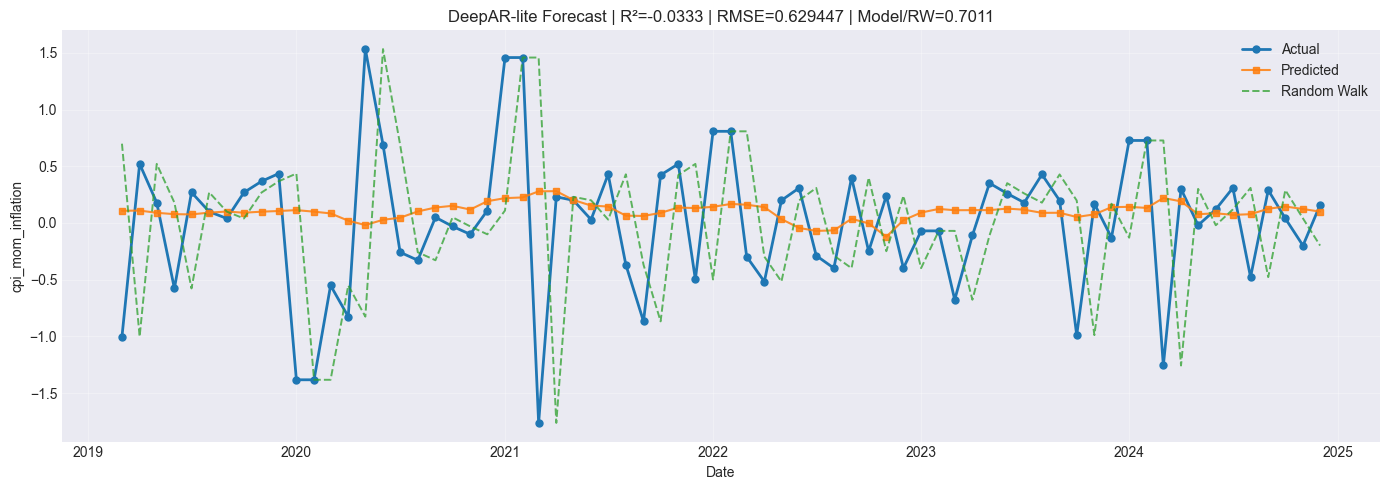

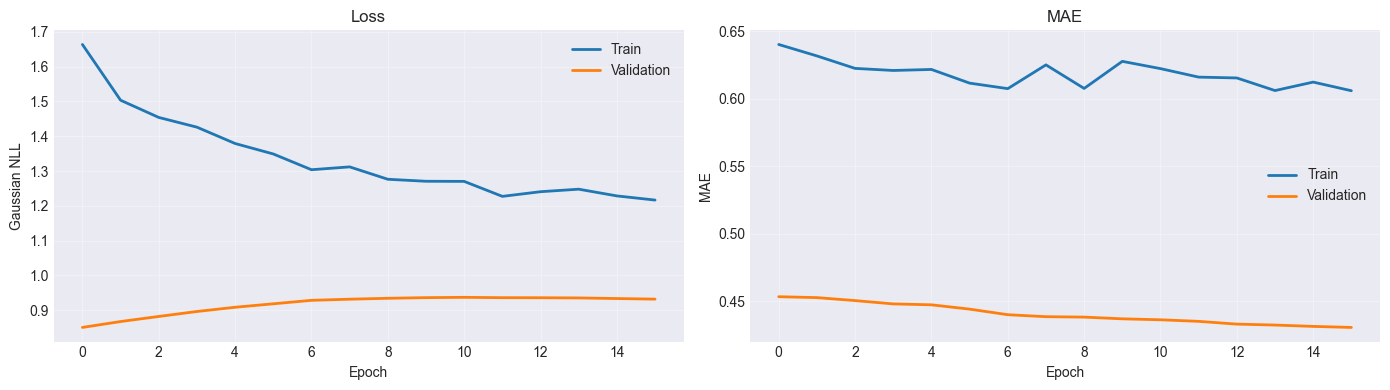

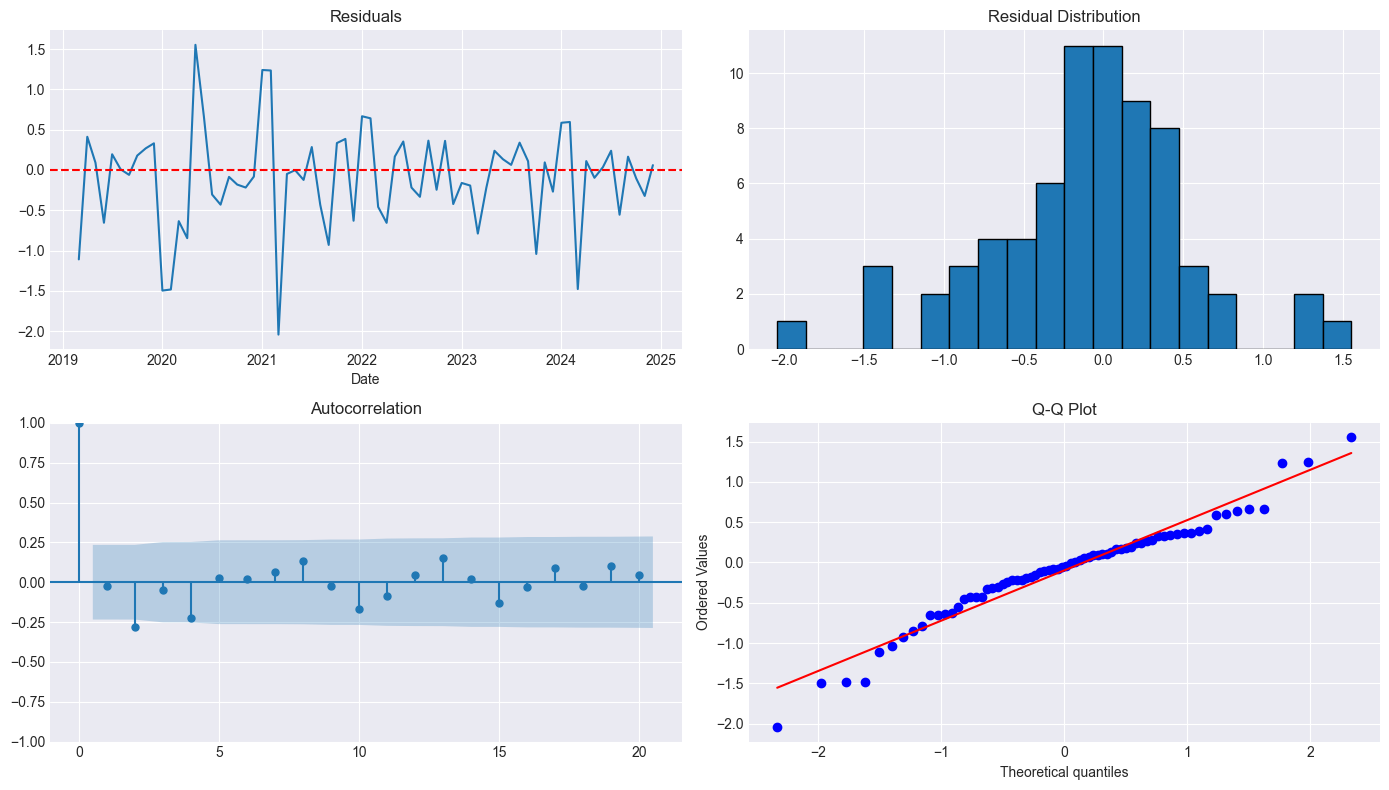


Residual diagnostics
Residual mean: -0.098432
Residual std:  0.621703
Jarque-Bera p-value: 0.036135


In [8]:
pred_params = model.predict(X_test_scaled, verbose=0)
y_pred_scaled = pred_params[:, 0]
y_sigma_scaled = np.log1p(np.exp(pred_params[:, 1])) + 1e-6
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_sigma = y_sigma_scaled * y_scaler.scale_[0]
y_test_actual = y_test.copy()

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

y_rw = df[target_col].shift(1).reindex(dates_test).values
mask = ~np.isnan(y_rw)
rmse_rw = np.sqrt(mean_squared_error(y_test_actual[mask], y_rw[mask]))
mae_rw = mean_absolute_error(y_test_actual[mask], y_rw[mask])
vs_rw = rmse / rmse_rw if rmse_rw > 0 else np.nan

y_mean = np.repeat(np.mean(y_test_actual), len(y_test_actual))
rmse_mean = np.sqrt(mean_squared_error(y_test_actual, y_mean))
vs_mean = rmse / rmse_mean if rmse_mean > 0 else np.nan

print("\nTest Results")
print(f"R²:                 {r2:.4f}")
print(f"RMSE:               {rmse:.6f}")
print(f"MAE:                {mae:.6f}")
print(f"Random Walk RMSE:   {rmse_rw:.6f}")
print(f"Random Walk MAE:    {mae_rw:.6f}")
print(f"Model / RW RMSE:    {vs_rw:.4f}")
print(f"Mean Baseline RMSE: {rmse_mean:.6f}")
print(f"Model / Mean RMSE:  {vs_mean:.4f}")
print(f"Average predictive sigma: {np.mean(y_sigma):.6f}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_test, y_test_actual, "o-", label="Actual", markersize=5, linewidth=2)
ax.plot(dates_test, y_pred, "s-", label="Predicted", markersize=4, linewidth=1.5, alpha=0.85)
ax.plot(dates_test[mask], y_rw[mask], "--", label="Random Walk", linewidth=1.4, alpha=0.75)
ax.set_title(f"{MODEL_NAME} Forecast | R²={r2:.4f} | RMSE={rmse:.6f} | Model/RW={vs_rw:.4f}")
ax.set_xlabel("Date")
ax.set_ylabel(target_col)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_forecast.png"), dpi=150)
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history["loss"], label="Train", linewidth=2)
ax1.plot(history.history["val_loss"], label="Validation", linewidth=2)
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel(LOSS_LABEL)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history["gaussian_mae"], label="Train", linewidth=2)

ax2.plot(history.history["val_gaussian_mae"], label="Validation", linewidth=2)
ax2.set_title("MAE")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MAE")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_training.png"), dpi=150)
plt.show()

residuals = y_test_actual - y_pred
max_lags = min(20, len(residuals) - 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(dates_test, residuals)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals")
axes[0, 0].set_xlabel("Date")
axes[0, 1].hist(residuals, bins=20, edgecolor="black")
axes[0, 1].set_title("Residual Distribution")
plot_acf(residuals, lags=max_lags, ax=axes[1, 0])
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_residuals.png"), dpi=150)
plt.show()

jb_stat, jb_p = jarque_bera(residuals)
print("\nResidual diagnostics")
print(f"Residual mean: {np.mean(residuals):.6f}")
print(f"Residual std:  {np.std(residuals):.6f}")
print(f"Jarque-Bera p-value: {jb_p:.6f}")

DeepAR setup
Target column: cpi_mom_inflation
Target included in features: True
Number of features: 11
Features: ['cpi_mom_inflation', 'dlog_broad_money', 'diff_ppi_qoq', 'dlog_wti', 'dlog_gold', 'diff_policy_rate', 'dlog_VNINDEX', 'dlog_NIKKEI225', 'dlog_USDVND', 'month_sin', 'month_cos']

Sequence creation
X shape: (347, 12, 11)
y shape: (347,)

Leakage check
X end date example: 1996-01-01
y date example:     1996-02-01
Correct if X end date is before y date.

Time split
Train: (242, 12, 11), 1996-02-01 to 2016-03-01
Val:   (35, 12, 11), 2016-04-01 to 2019-02-01
Test:  (70, 12, 11), 2019-03-01 to 2024-12-01


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12, 11)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 12, 32)         │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,074 (35.45 KB)

 Trainable params: 9,074 (35.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - gaussian_mae: 0.6338 - loss: 1.5884 - val_gaussian_mae: 0.4378 - val_loss: 0.8357 - learning_rate: 5.0000e-04
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - gaussian_mae: 0.6299 - loss: 1.5518 - val_gaussian_mae: 0.4389 - val_loss: 0.8506 - learning_rate: 5.0000e-04
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - gaussian_mae: 0.6297 - loss: 1.5473 - val_gaussian_mae: 0.4390 - val_loss: 0.8648 - learning_rate: 5.0000e-04
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - gaussian_mae: 0.6312 - loss: 1.4963 - val_gaussian_mae: 0.4400 - val_loss: 0.8808 - learning_rate: 5.0000e-04
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - gaussian_mae: 0.6315 - loss: 1.4600 - val_gaussian_mae: 0.4409 - val_loss: 0.8977 - learning_rate: 5.0000e-04
Epoch 6/200
11/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - gaussian_mae: 0.7864 - loss: 1.6992 
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
16/16 ━━━━━━━━━━

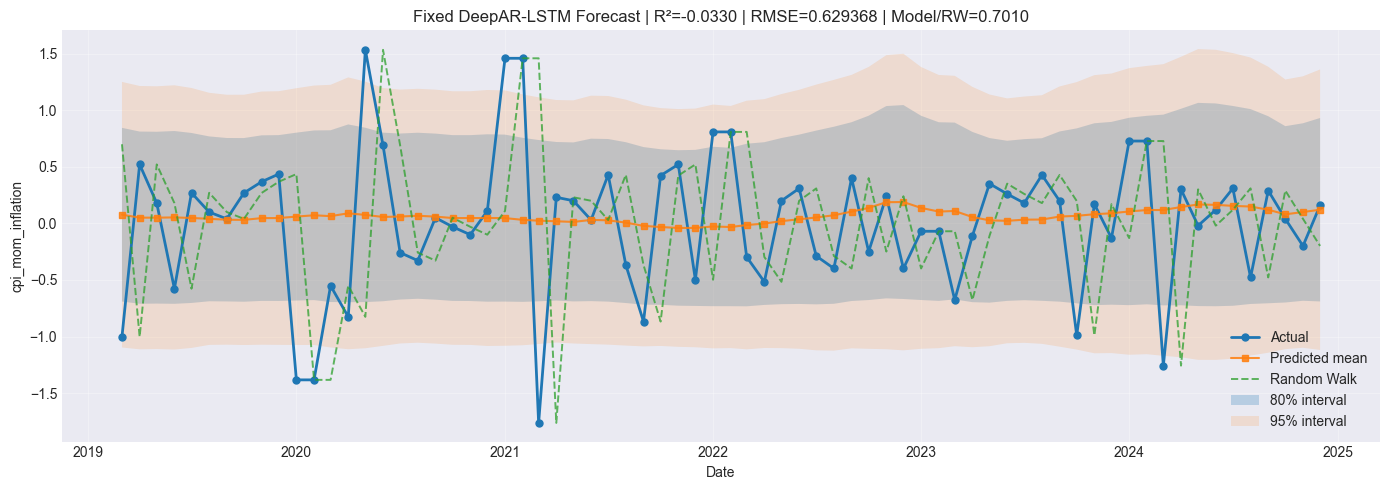

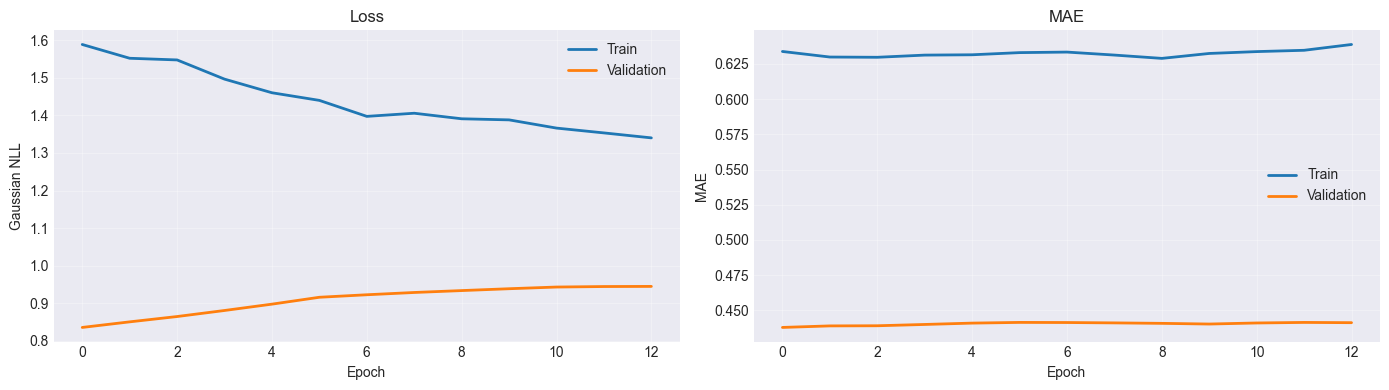

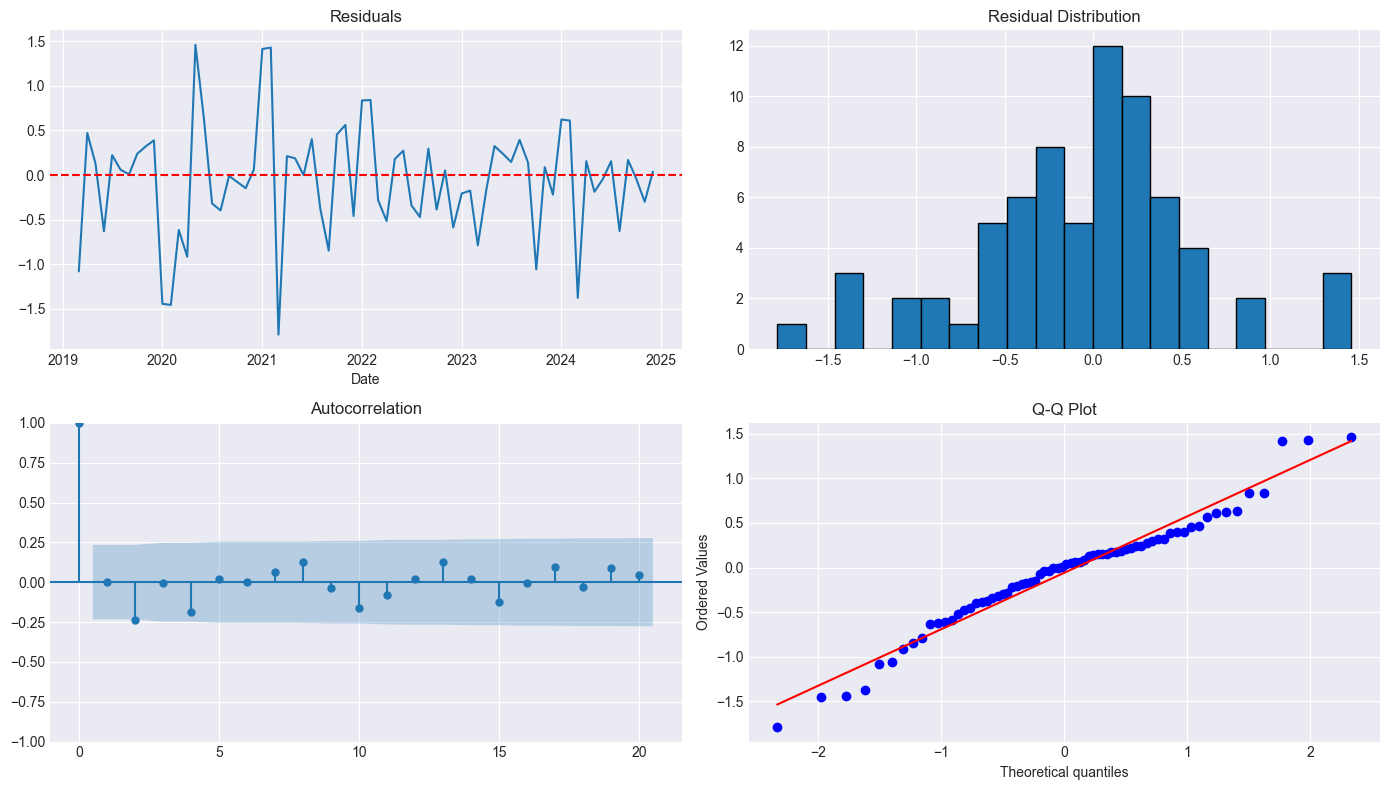


Residual diagnostics
Residual mean: -0.058701
Residual std:  0.626625
Jarque-Bera p-value: 0.318899


In [11]:
# ============================================================
# Fixed + Improved DeepAR-lite with lagged inflation
# ============================================================

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import L1L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from scipy.stats import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats

# -----------------------------
# 1. Reset seed/session
# -----------------------------
SEED = 42
tf.keras.backend.clear_session()
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_DIR = os.path.join(os.getcwd(), "outputs", "step8_deepar_fixed")
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_NAME = "Fixed DeepAR-LSTM"
MODEL_TAG = "fixed_deepar_lstm"
LOSS_LABEL = "Gaussian NLL"

# -----------------------------
# 2. Add lagged inflation + date-time encoding
# -----------------------------
def add_datetime_features(df):
    out = df.copy()
    month = out.index.month.values
    out["month_sin"] = np.sin(2 * np.pi * month / 12)
    out["month_cos"] = np.cos(2 * np.pi * month / 12)
    return out

df_model = add_datetime_features(df)

# Important: include target as lagged autoregressive feature
# This is safe because X uses only t-12 ... t-1.
feature_cols_deepar = list(df.columns) + ["month_sin", "month_cos"]

print("DeepAR setup")
print(f"Target column: {target_col}")
print(f"Target included in features: {target_col in feature_cols_deepar}")
print(f"Number of features: {len(feature_cols_deepar)}")
print(f"Features: {feature_cols_deepar}")

# -----------------------------
# 3. Create supervised sequences
# -----------------------------
def create_supervised_sequences(df, target_col, feature_cols, window=12, horizon=1):
    X, y, dates = [], [], []

    for i in range(window, len(df) - horizon + 1):
        X.append(df[feature_cols].iloc[i-window:i].values)
        y.append(df[target_col].iloc[i + horizon - 1])
        dates.append(df.index[i + horizon - 1])

    return np.array(X), np.array(y), pd.Index(dates)

window = 12
horizon = 1

X, y, y_dates = create_supervised_sequences(
    df=df_model,
    target_col=target_col,
    feature_cols=feature_cols_deepar,
    window=window,
    horizon=horizon
)

print("\nSequence creation")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("\nLeakage check")
print(f"X end date example: {df_model.index[window-1].date()}")
print(f"y date example:     {df_model.index[window].date()}")
print("Correct if X end date is before y date.")

# -----------------------------
# 4. Time-based split
# -----------------------------
n = len(X)
train_end = int(0.70 * n)
val_end = int(0.80 * n)

X_train, y_train, dates_train = X[:train_end], y[:train_end], y_dates[:train_end]
X_val, y_val, dates_val = X[train_end:val_end], y[train_end:val_end], y_dates[train_end:val_end]
X_test, y_test, dates_test = X[val_end:], y[val_end:], y_dates[val_end:]

print("\nTime split")
print(f"Train: {X_train.shape}, {dates_train[0].date()} to {dates_train[-1].date()}")
print(f"Val:   {X_val.shape}, {dates_val[0].date()} to {dates_val[-1].date()}")
print(f"Test:  {X_test.shape}, {dates_test[0].date()} to {dates_test[-1].date()}")

# -----------------------------
# 5. Scaling
# -----------------------------
n_train, p, d = X_train.shape

x_scaler = RobustScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train.reshape(-1, d)).reshape(X_train.shape)
X_val_scaled = x_scaler.transform(X_val.reshape(-1, d)).reshape(X_val.shape)
X_test_scaled = x_scaler.transform(X_test.reshape(-1, d)).reshape(X_test.shape)

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

# -----------------------------
# 6. Stable Gaussian NLL
# -----------------------------
def gaussian_nll(y_true, y_pred):
    y_true = tf.reshape(y_true, [-1])

    mu = y_pred[:, 0]
    raw_sigma = y_pred[:, 1]

    # Stable positive sigma
    sigma = tf.nn.softplus(raw_sigma) + 1e-4

    nll = (
        0.5 * tf.math.log(2.0 * np.pi)
        + tf.math.log(sigma)
        + 0.5 * tf.square((y_true - mu) / sigma)
    )

    return tf.reduce_mean(nll)

def gaussian_mae(y_true, y_pred):
    y_true = tf.reshape(y_true, [-1])
    mu = y_pred[:, 0]
    return tf.reduce_mean(tf.abs(y_true - mu))

# -----------------------------
# 7. Build DeepAR-LSTM
# -----------------------------
def build_deepar_lstm(window, n_features, units=32, dropout=0.20, lr=0.0005):
    inputs = Input(shape=(window, n_features))

    x = LSTM(
        units,
        return_sequences=True,
        kernel_regularizer=L1L2(l1=1e-5, l2=1e-4)
    )(inputs)
    x = Dropout(dropout)(x)

    x = LSTM(
        units // 2,
        return_sequences=False,
        kernel_regularizer=L1L2(l1=1e-5, l2=1e-4)
    )(x)
    x = Dropout(dropout)(x)

    x = Dense(16, activation="relu")(x)

    # Output 2 parameters:
    # output[:, 0] = mu
    # output[:, 1] = raw sigma
    outputs = Dense(2)(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=gaussian_nll,
        metrics=[gaussian_mae]
    )

    return model

model = build_deepar_lstm(
    window=window,
    n_features=len(feature_cols_deepar),
    units=32,
    dropout=0.20,
    lr=0.0005
)

model.summary()

# -----------------------------
# 8. Train
# -----------------------------
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=12,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=200,
    batch_size=16,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)

# -----------------------------
# 9. Prediction
# -----------------------------
pred_params = model.predict(X_test_scaled, verbose=0)

y_pred_scaled = pred_params[:, 0]
y_sigma_scaled = np.log1p(np.exp(pred_params[:, 1])) + 1e-4

y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_sigma = y_sigma_scaled * y_scaler.scale_[0]

y_test_actual = y_test.copy()

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

# Random Walk benchmark
y_rw = df[target_col].shift(1).reindex(dates_test).values
mask = ~np.isnan(y_rw)

rmse_rw = np.sqrt(mean_squared_error(y_test_actual[mask], y_rw[mask]))
mae_rw = mean_absolute_error(y_test_actual[mask], y_rw[mask])
vs_rw = rmse / rmse_rw if rmse_rw > 0 else np.nan

# Mean baseline
y_mean = np.repeat(np.mean(y_test_actual), len(y_test_actual))
rmse_mean = np.sqrt(mean_squared_error(y_test_actual, y_mean))
mae_mean = mean_absolute_error(y_test_actual, y_mean)
vs_mean = rmse / rmse_mean if rmse_mean > 0 else np.nan

print("\n" + "="*80)
print("FIXED DEEPAR-LSTM TEST RESULTS")
print("="*80)
print(f"R²:                 {r2:.4f}")
print(f"RMSE:               {rmse:.6f}")
print(f"MAE:                {mae:.6f}")
print(f"Random Walk RMSE:   {rmse_rw:.6f}")
print(f"Random Walk MAE:    {mae_rw:.6f}")
print(f"Model / RW RMSE:    {vs_rw:.4f}")
print(f"Mean Baseline RMSE: {rmse_mean:.6f}")
print(f"Mean Baseline MAE:  {mae_mean:.6f}")
print(f"Model / Mean RMSE:  {vs_mean:.4f}")
print(f"Average sigma:      {np.mean(y_sigma):.6f}")
print("="*80)

# -----------------------------
# 10. Prediction interval
# -----------------------------
z80, z95 = 1.2816, 1.96

lower80 = y_pred - z80 * y_sigma
upper80 = y_pred + z80 * y_sigma

lower95 = y_pred - z95 * y_sigma
upper95 = y_pred + z95 * y_sigma

coverage80 = np.mean((y_test_actual >= lower80) & (y_test_actual <= upper80))
coverage95 = np.mean((y_test_actual >= lower95) & (y_test_actual <= upper95))

print("\nPrediction interval diagnostics")
print(f"80% interval empirical coverage: {coverage80:.4f}")
print(f"95% interval empirical coverage: {coverage95:.4f}")

# -----------------------------
# 11. Forecast plot
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(dates_test, y_test_actual, "o-", label="Actual", markersize=5, linewidth=2)
ax.plot(dates_test, y_pred, "s-", label="Predicted mean", markersize=4, linewidth=1.5, alpha=0.85)
ax.plot(dates_test[mask], y_rw[mask], "--", label="Random Walk", linewidth=1.4, alpha=0.75)

ax.fill_between(dates_test, lower80, upper80, alpha=0.25, label="80% interval")
ax.fill_between(dates_test, lower95, upper95, alpha=0.15, label="95% interval")

ax.set_title(
    f"{MODEL_NAME} Forecast | R²={r2:.4f} | RMSE={rmse:.6f} | Model/RW={vs_rw:.4f}"
)
ax.set_xlabel("Date")
ax.set_ylabel(target_col)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_forecast.png"), dpi=150)
plt.show()

# -----------------------------
# 12. Training curve
# -----------------------------
metric_key = "gaussian_mae"
val_metric_key = "val_gaussian_mae"

if metric_key not in history.history:
    metric_key = [k for k in history.history.keys() if "mae" in k and not k.startswith("val_")][0]
    val_metric_key = "val_" + metric_key

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history["loss"], label="Train", linewidth=2)
ax1.plot(history.history["val_loss"], label="Validation", linewidth=2)
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Gaussian NLL")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history[metric_key], label="Train", linewidth=2)
ax2.plot(history.history[val_metric_key], label="Validation", linewidth=2)
ax2.set_title("MAE")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MAE")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_training.png"), dpi=150)
plt.show()

# -----------------------------
# 13. Residual diagnostics
# -----------------------------
residuals = y_test_actual - y_pred
max_lags = min(20, len(residuals) - 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(dates_test, residuals)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals")
axes[0, 0].set_xlabel("Date")

axes[0, 1].hist(residuals, bins=20, edgecolor="black")
axes[0, 1].set_title("Residual Distribution")

plot_acf(residuals, lags=max_lags, ax=axes[1, 0])
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_residuals.png"), dpi=150)
plt.show()

jb_stat, jb_p = jarque_bera(residuals)

print("\nResidual diagnostics")
print(f"Residual mean: {np.mean(residuals):.6f}")
print(f"Residual std:  {np.std(residuals):.6f}")
print(f"Jarque-Bera p-value: {jb_p:.6f}")